Saved figure to: ami_archetypes.svg


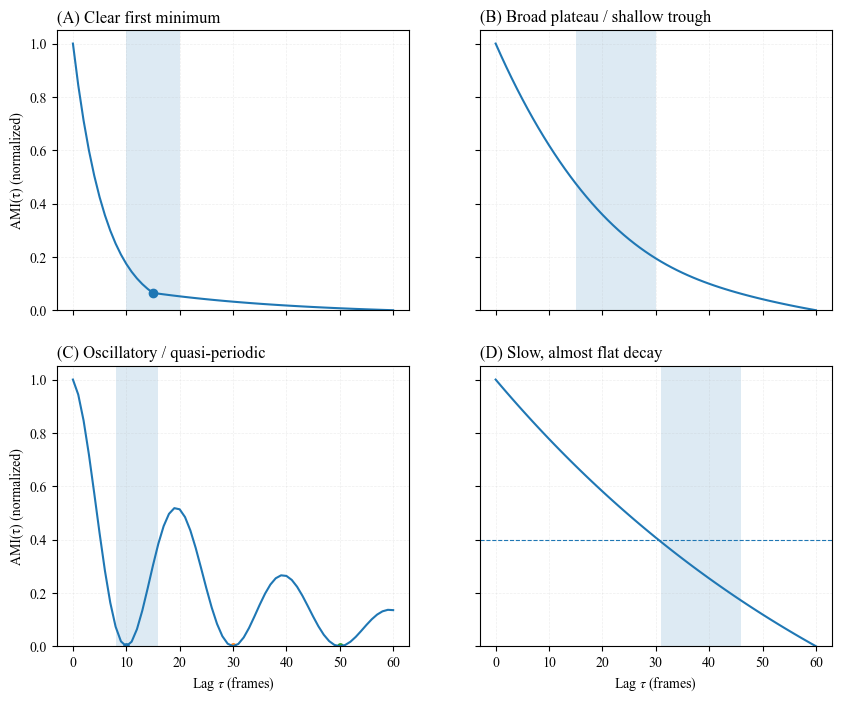

In [8]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Times-Roman"],
    "mathtext.fontset": "stix",  # math text that matches Times-like look
    "axes.unicode_minus": False,  # ensure minus sign looks correct with Times
})

def generate_ami_archetypes():
    """
    Generate four stylized AMI-like curves for illustrative purposes:
    (A) Clear first minimum
    (B) Broad plateau / shallow trough
    (C) Oscillatory / quasi-periodic
    (D) Slow, almost flat decay (high redundancy)
    """
    tau = np.arange(0, 61)  # 0–60 frames

    # (A) Textbook clear first minimum:
    ami_A = np.zeros_like(tau, dtype=float)
    fast = np.exp(-tau / 6.0)  # steep early decay
    # after tau≈15, decay continues but much more slowly
    slow = np.exp(-(tau - 15) / 30.0) * np.exp(-15 / 6.0)
    ami_A[tau <= 15] = fast[tau <= 15]
    ami_A[tau > 15] = slow[tau > 15]
    ami_A = (ami_A - ami_A.min()) / (ami_A.max() - ami_A.min())

    # (B) Broad plateau / shallow trough:
    # Mild decay to a wide, almost flat region, tiny U-shape
    base_B = 0.25 + 0.75 * np.exp(-tau / 25.0)
    trough_B = -0.03 * np.exp(-(tau - 25)**2 / (2 * 15**2))
    ami_B = base_B + trough_B
    ami_B = (ami_B - ami_B.min()) / (ami_B.max() - ami_B.min())

    # (C) Oscillatory / quasi-periodic:
    # Exponential envelope times a cosine, shifted to be positive
    envelope_C = np.exp(-tau / 30.0)
    osc_C = 0.5 * (1 + np.cos(2 * np.pi * tau / 20.0))  # between 0 and 1
    ami_C = 0.15 + 0.8 * envelope_C * osc_C
    ami_C = (ami_C - ami_C.min()) / (ami_C.max() - ami_C.min())

    # (D) Slow, almost flat decay (high redundancy):
    # Very slow exponential decay, staying high for a long range
    ami_D = 0.2 + 0.8 * np.exp(-tau / 80.0)
    ami_D = (ami_D - ami_D.min()) / (ami_D.max() - ami_D.min())

    return tau, ami_A, ami_B, ami_C, ami_D


def plot_ami_archetypes(save_path="ami_archetypes.svg"):
    tau, ami_A, ami_B, ami_C, ami_D = generate_ami_archetypes()

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axA, axB, axC, axD = axes.flatten()

    # Common y-limits for a clean look
    for ax in [axA, axB, axC, axD]:
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)

    # ----------------- Panel (A): Clear first minimum -----------------
    axA.plot(tau, ami_A)
    axA.set_title("(A) Clear first minimum", loc="left")

    # Choose a "textbook" tau* around 15 and mark it
    tau_star_A = 15
    idx_star_A = np.where(tau == tau_star_A)[0][0]
    axA.scatter(tau_star_A, ami_A[idx_star_A], zorder=3)
    axA.axvspan(10, 20, alpha=0.15)  # neighborhood band
    #axA.text(10.5, 0.9, r"Use $\tau$ in a small neighborhood",
             #fontsize=9, va="top")

    # ----------------- Panel (B): Broad plateau -----------------
    axB.plot(tau, ami_B)
    axB.set_title("(B) Broad plateau / shallow trough", loc="left")
    axB.axvspan(15, 30, alpha=0.15)
    #axB.text(15.5, 0.9, r"No unique $\tau$ – use band",
             #fontsize=9, va="top")

    # ----------------- Panel (C): Oscillatory / quasi-periodic -----------------
    axC.plot(tau, ami_C)
    axC.set_title("(C) Oscillatory / quasi-periodic", loc="left")

    # Mark several local minima (just pick a region near first "valley")
    candidate_minima = [10, 30, 50]  # illustrative
    for t_min in candidate_minima:
        idx = np.where(tau == t_min)[0]
        if len(idx) > 0:
            idx = idx[0]
            axC.scatter(t_min, ami_C[idx], s=15)

    axC.axvspan(8, 16, alpha=0.15)
    #axC.text(8.5, 0.9,
             #r"Multiple scales – pick earliest broad minimum",
             #fontsize=9, va="top")

    # ----------------- Panel (D): Slow decay / high redundancy -----------------
    axD.plot(tau, ami_D)
    axD.set_title("(D) Slow, almost flat decay", loc="left")

    # Example "threshold" where AMI has clearly dropped
    # Here we just pick where ami_D < 0.4 as an illustrative cutoff
    threshold = 0.4
    # First tau where curve falls below threshold (if any)
    below = np.where(ami_D < threshold)[0]
    if len(below) > 0:
        tau_thresh = tau[below[0]]
        axD.axhline(threshold, linestyle="--", linewidth=0.8)
        axD.axvspan(tau_thresh, tau_thresh + 15, alpha=0.15)
        #axD.text(tau_thresh + 0.5, threshold + 0.05,
                # r"Signal highly redundant at short lags",
                 #fontsize=9, va="bottom")

    # ----------------- Axis labels -----------------
    for ax in [axC, axD]:
        ax.set_xlabel(r"Lag $\tau$ (frames)")

    for ax in [axA, axC]:
        ax.set_ylabel("AMI(τ) (normalized)")

    #fig.suptitle("Archetypal Average Mutual Information (AMI) Profiles", fontsize=14)
    #plt.tight_layout(rect=[0, 0, 1, 0.96])

    plt.savefig(save_path, dpi=300)
    print(f"Saved figure to: {save_path}")


if __name__ == "__main__":
    plot_ami_archetypes()
